# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Carter Moorefield

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Carter Moorefield
Your Kaggle Key: ··········
Your Kaggle Key: ··········
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:06<00:00, 65.8MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [5]:
# count the files in directories
fire_dir = 'fire-dataset/fire_dataset/fire_images'
non_fire_dir = 'fire-dataset/fire_dataset/non_fire_images'

num_fire = len(os.listdir(fire_dir))
num_non_fire = len(os.listdir(non_fire_dir))

print(f"Number of Fire Images: {num_fire}")
print(f"Number of Non-Fire Images: {num_non_fire}")
print(f"Imbalance Ratio (Fire/Non-Fire): {num_fire / num_non_fire:.2f}")

Number of Fire Images: 755
Number of Non-Fire Images: 244
Imbalance Ratio (Fire/Non-Fire): 3.09


*What did you notice about this dataset? Does it change how you'll approach the next steps?*



The dataset includes more Non-Fire images than Fire images.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [ ]:
# Preprocess the data here



In [9]:
# Preprocess the data using MobileNetV2 preprocess_input function
def preprocess_data(image, label):
    # MobileNetV2 expects inputs in range [-1, 1]
    return preprocess_input(image), label

train_fire = train_raw_fire.map(preprocess_data)
val_fire = val_raw_fire.map(preprocess_data)
test_fire = test_raw_fire.map(preprocess_data)

# Prefetching for performance
AUTOTUNE = tf.data.AUTOTUNE
train_fire = train_fire.prefetch(buffer_size=AUTOTUNE)
val_fire = val_fire.prefetch(buffer_size=AUTOTUNE)
test_fire = test_fire.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Build your model here



In [10]:
# Build the model here using a frozen MobileNetV2 base
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base entirely

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # Keep batch normalization layers in inference mode
x = GlobalAveragePooling2D()(x)
# Since it is a binary classification (fire_images vs non_fire_images), we use 1 unit with a sigmoid activation
outputs = Dense(1, activation='sigmoid')(x)

model_fire = Model(inputs, outputs)
model_fire.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile your model here



In [11]:
# Compile the model
model_fire.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 1D — Train and Evaluate

In [12]:
# Train your model here
history_fire = model_fire.fit(
    train_fire,
    epochs=10,
    validation_data=val_fire
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7400 - loss: 0.4703 - val_accuracy: 0.9209 - val_loss: 0.2559
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9586 - loss: 0.1878 - val_accuracy: 0.9712 - val_loss: 0.1339
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9629 - loss: 0.1221 - val_accuracy: 0.9640 - val_loss: 0.1107
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9771 - loss: 0.0971 - val_accuracy: 0.9712 - val_loss: 0.0854
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9814 - loss: 0.0818 - val_accuracy: 0.9784 - val_loss: 0.0716
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9886 - loss: 0.0724 - val_accuracy: 0.9712 - val_loss: 0.0918
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9900 - loss: 0.0645 - val_accuracy: 0.9640 - val_loss: 0.0907
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9914 - loss: 0.0590 - val_accuracy: 0.9784 - val_loss:

In [13]:
# Report validation and test accuracy here
val_loss, val_acc = model_fire.evaluate(val_fire, verbose=0)
test_loss, test_acc = model_fire.evaluate(test_fire, verbose=0)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Validation Accuracy: 0.9784
Test Accuracy: 0.9812


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

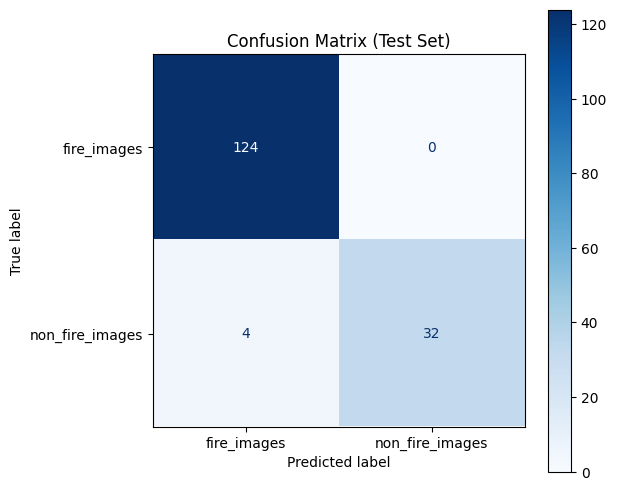

In [14]:
# true labels and predictions on test set
y_true = []
y_pred = []

for images, labels in test_fire:
    preds = model_fire.predict(images, verbose=0)
    # labels are binary (0 for fire_images, 1 for non_fire_images)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Test Set)")
plt.show()

A false negative (missing a real fire) is much costlier than a false positive, as there are far less real fire images in the data set than non-fire images. In practice, we would decrease the decision threshold to a lower value, so that it would be far more sensitive to signs of fire images. We would get more false positives, but it could theoretically increase accuracy compared to more false negatives.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [ ]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

In [9]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

NameError: name 'img_size' is not defined

## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [ ]:
# Preprocess the data here



In [ ]:
# Preprocess the EuroSAT dataset using MobileNetV2 preprocess_input
def preprocess_data_sat(image, label):
    return preprocess_input(image), label

# Cache the datasets in memory to speed up training dramatically
train_sat = train_raw_sat.map(preprocess_data_sat).cache()
val_sat = val_raw_sat.map(preprocess_data_sat).cache()
test_sat = test_raw_sat.map(preprocess_data_sat).cache()

# Prefetching for performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_sat = train_sat.prefetch(buffer_size=AUTOTUNE)
val_sat = val_sat.prefetch(buffer_size=AUTOTUNE)
test_sat = test_sat.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Build your model here



In [ ]:
# Build the model using a frozen MobileNetV2 base for EuroSAT
base_model_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_sat.trainable = False  # Freeze the base entirely

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
# 10 output units for the 10 land-use classes, with softmax activation
outputs = Dense(10, activation='softmax')(x)

model_sat = Model(inputs, outputs)
model_sat.summary()

In [ ]:
# Compile your model here



In [ ]:
# Compile the model using sparse categorical crossentropy
model_sat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 2C — Train and Evaluate

In [ ]:
# Train your model here



In [ ]:
# Train the EuroSAT model with reduced epochs (3) to lower computational load
history_sat = model_sat.fit(
    train_sat,
    epochs=3,
    validation_data=val_sat
)

In [ ]:
# Report validation and test accuracy here



In [ ]:
# Report validation and test accuracy for EuroSAT
val_loss_sat, val_acc_sat = model_sat.evaluate(val_sat, verbose=0)
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat, verbose=0)

print(f"Validation Accuracy (EuroSAT): {val_acc_sat:.4f}")
print(f"Test Accuracy (EuroSAT): {test_acc_sat:.4f}")

## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

In [ ]:
# Build your confusion matrix here



*Your answer:*




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 0.9784 | |
| Test Accuracy | 0.9812 | |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.